## Case Study

### Business Questions:
1. Berapa total revenue dan komposisi per kategori produk?
2. Channel penjualan mana yang paling menguntungkan?
3. Bagaimana tren penjualan per bulan?
4. Produk apa yang paling laris?
5. Kota mana dengan penjualan tertinggi?
6. Bagaimana distribusi status order dan rating pelanggan?
7.  Siapa pelanggan paling aktif? Temukan Top 10 pelanggan berdasarkan jumlah order dan total belanja mereka
8. Kategori produk mana yang paling laris di tiap channel? Bandingkan performa setiap kategori (Makanan, Pembersih, Perawatan) di masing-masing channel penjualan (Offline, Online Toko Oren, Online Toko Hijau), mana yang mendominasi di tiap channel?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load dataset
# Jika di Google Colab: upload file atau mount Google Drive terlebih dahulu
df_raw = pd.read_csv('/content/Data FMCG_BT Data Analyst - Messy.xlsx - Sales Data.csv', sep=',')

print(f'Shape awal : {df_raw.shape}')
print(f'Kolom      : {df_raw.columns.tolist()}')
print()
df_raw.head(10)

Shape awal : (20006, 15)
Kolom      : ['sales_date', 'order_id', 'product_name', 'category', 'price', 'quantity', 'total', 'discount', 'shipping_fee', 'total_sales', 'customer_name', 'customer_address', 'channel', 'rating', 'status']



,sales_date,order_id,product_name,category,price,quantity,total,discount,shipping_fee,total_sales,customer_name,customer_address,channel,rating,status
0,1/1/2025,P00001,Minyak Goreng,Makanan,18000,1,NaN,"0,15",20000,NaN,Shinta,Malang,Toko_Oren_Online,5,Returned
1,1/1/2025,P00002,Kopi,Makanan,25000,3,NaN,"0,15",22000,NaN,Eli,Makassar,Offline,4,Failed
2,1/1/2025,P00003,Deterjen,PEMBERSIH,10000,3,NaN,"0,15",25000,NaN,Eka,Medan,Offline,1,Pending
3,1/1/2025,P00004,Minyak Goreng,makanan,18000,1,NaN,"0,15",20000,NaN,Zenia,Surabaya,Online - Toko Oren,3,Pending
4,1/1/2025,P00005,Pasta Gigi,Perawatan,15000,3,NaN,"0,15",12000,NaN,Dicky,Bogor,Online - Toko Oren,1,Returned
5,1/1/2025,P00006,Minyak Goreng,makanan,18000,3,NaN,"0,15",22000,NaN,Santi,Makassar,Online - Toko Oren,1,Pending
6,1/1/2025,P00007,Sabun Mandi,PEMBERSIH,7000,3,NaN,"0,15",25000,NaN,Farhan,Medan,Offline,5,Failed
7,1/1/2025,P00008,Pembersih Lantai,pembersih,8000,1,NaN,"0,15",22000,NaN,Dewa,Makassar,Online - Toko Oren,1,Sukses
8,1/1/2025,P00009,Pasta Gigi,PERAWATAN,15000,3,NaN,"0,15",30000,NaN,Zara,Samarinda,Offline,5,Pending
9,1/1/2025,P00010,Shampo,PERAWATAN,20000,2,NaN,"0,15",18000,NaN,Putra,Yogyakarta,Online - Toko Hijau,5,Failed


## 1. Eksplorasi Struktur Data

In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20006 entries, 0 to 20005
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sales_date        20006 non-null  object 
 1   order_id          20006 non-null  object 
 2   product_name      20006 non-null  object 
 3   category          20006 non-null  object 
 4   price             20006 non-null  int64  
 5   quantity          20006 non-null  int64  
 6   total             0 non-null      float64
 7   discount          20006 non-null  object 
 8   shipping_fee      20006 non-null  int64  
 9   total_sales       0 non-null      float64
 10  customer_name     20006 non-null  object 
 11  customer_address  20006 non-null  object 
 12  channel           20006 non-null  object 
 13  rating            20006 non-null  int64  
 14  status            20006 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 2.3+ MB


In [ ]:
df_raw.describe()

,price,quantity,total,shipping_fee,total_sales,rating
count,20006.000000,20006.000000,0.0,20006.000000,0.0,20006.00000
mean,13506.398081,1.971659,NaN,17061.881436,NaN,2.99900
std,6004.658198,1.793416,NaN,7081.753436,NaN,1.41873
min,5000.000000,-99.000000,NaN,0.000000,NaN,1.00000
25%,8000.000000,1.000000,NaN,12000.000000,NaN,2.00000
50%,15000.000000,2.000000,NaN,18000.000000,NaN,3.00000
75%,18000.000000,3.000000,NaN,22000.000000,NaN,4.00000
max,25000.000000,3.000000,NaN,30000.000000,NaN,5.00000


## 2. Identifikasi Masalah Data

In [ ]:
df_raw[df_raw['quantity']<=0]

,sales_date,order_id,product_name,category,price,quantity,total,discount,shipping_fee,total_sales,customer_name,customer_address,channel,rating,status
14,1/1/2025,P00015,Kopi,Makanan,25000,-99,NaN,"0,15",25000,NaN,Mutiara,Medan,Offline,1,Sukses
134,1/3/2025,P00133,Pembersih Wajah,Perawatan,12000,-99,NaN,0,15000,NaN,Vera,Jakarta,Online - Toko Hijau,5,Failed
174,1/4/2025,P00173,Pembersih Wajah,PERAWATAN,12000,-99,NaN,0,20000,NaN,Irma,Malang,hijau_toko_web,3,Returned
235,1/5/2025,P00233,Shampo,PERAWATAN,20000,-99,NaN,0,20000,NaN,Gilang,Malang,Offline,5,Sukses
285,1/6/2025,P00283,Minyak Goreng,Makanan,18000,-99,NaN,0,20000,NaN,Cindy,Malang,Online - Toko Hijau,2,Failed


In [ ]:
print('=== 1. MISSING VALUES ===')
missing = df_raw.isnull().sum()
persen  = (missing / len(df_raw) * 100).round(2)
print(pd.DataFrame({'Jumlah Missing': missing, 'Persen (%)': persen}))

print(f'\n=== 2. DATA DUPLIKAT ===')
print(f'Jumlah baris duplikat: {df_raw.duplicated().sum()}')

print(f'\n=== 3. NILAI UNIK KOLOM KATEGORIKAL ===')
for col in ['category', 'channel', 'status']:
    print(f'{col:10}: {df_raw[col].unique()}')

print(f'\n=== 4. QUANTITY TIDAK VALID (<=0) ===')
print(df_raw[df_raw['quantity'] <= 0][['order_id', 'product_name', 'quantity']])

print(f'\n=== 5. PRODUCT_NAME DENGAN SPASI ===')
spasi = df_raw[df_raw['product_name'].str.startswith(' ', na=False)]['product_name'].unique()
print(spasi)

=== 1. MISSING VALUES ===
                  Jumlah Missing  Persen (%)
sales_date                     0         0.0
order_id                       0         0.0
product_name                   0         0.0
category                       0         0.0
price                          0         0.0
quantity                       0         0.0
total                      20006       100.0
discount                       0         0.0
shipping_fee                   0         0.0
total_sales                20006       100.0
customer_name                  0         0.0
customer_address               0         0.0
channel                        0         0.0
rating                         0         0.0
status                         0         0.0

=== 2. DATA DUPLIKAT ===
Jumlah baris duplikat: 6

=== 3. NILAI UNIK KOLOM KATEGORIKAL ===
category  : ['Makanan' 'PEMBERSIH' 'makanan' 'Perawatan' 'pembersih' 'PERAWATAN'
 'Pembersih' 'MAKANAN' 'perawatan']
channel   : ['Toko_Oren_Online' 'Offline' 'On

## 3. Data Cleansing


In [ ]:
df = df_raw.copy()

# --- 1. Hapus kolom tidak relevan ---
df = df.drop(columns=['total', 'total_sales'])
print(f'Setelah drop kolom  : {df.shape}')

# --- 2. Hapus baris missing values ---
df = df.dropna(how='any').reset_index(drop=True)
print(f'Setelah drop NA     : {df.shape}')

# --- 3. Hapus duplikat ---
df = df.drop_duplicates(keep='first').reset_index(drop=True)
print(f'Setelah drop dup    : {df.shape}')

# --- 4. Hapus quantity tidak valid ---
df = df[df['quantity'] > 0].reset_index(drop=True)
print(f'Setelah hapus qty<=0: {df.shape}')

Setelah drop kolom  : (20006, 13)
Setelah drop NA     : (20006, 13)
Setelah drop dup    : (20000, 13)
Setelah hapus qty<=0: (19995, 13)


In [ ]:
# --- 5. Bersihkan product_name ---
df['product_name'] = df['product_name'].str.strip().str.title()

# --- 6. Standarisasi category ---
df['category'] = df['category'].str.strip().str.title()

# --- 7. Standarisasi channel ---
channel_map = {
    'Toko_Oren_Online'   : 'Online - Toko Oren',
    'hijau_toko_web'     : 'Online - Toko Hijau',
    'Offline'            : 'Offline',
    'Online - Toko Oren' : 'Online - Toko Oren',
    'Online - Toko Hijau': 'Online - Toko Hijau'
}
df['channel'] = df['channel'].map(channel_map)

# --- Standarisasi teks lainnya ---
df['customer_name']    = df['customer_name'].str.strip().str.title()
df['customer_address'] = df['customer_address'].str.strip().str.title()

print('Nilai unik category setelah cleaning:', df['category'].unique())
print('Nilai unik channel  setelah cleaning:', df['channel'].unique())

Nilai unik category setelah cleaning: ['Makanan' 'Pembersih' 'Perawatan']
Nilai unik channel  setelah cleaning: ['Online - Toko Oren' 'Offline' 'Online - Toko Hijau']


## 4. Data Formatting

In [ ]:
import pandas.api.types as pdat
f = df[df['sales_date'] != '12/31/2025']

# Format tanggal
df['sales_date'] = pd.to_datetime(df['sales_date'], format='%m/%d/%Y')

# Ekstrak komponen tanggal
df['month']      = df['sales_date'].dt.month
df['month_name'] = df['sales_date'].dt.strftime('%B')
df['quarter']    = df['sales_date'].dt.quarter

# Perbaiki tipe data numerik
df['price']        = df['price'].astype(float)
df['quantity']     = df['quantity'].astype(int)

# Conditionally apply str.replace if 'discount' is still an object (string)
if pdat.is_string_dtype(df['discount']):
    df['discount'] = df['discount'].str.replace(',', '.').astype(float)
else:
    # If it's not a string, it should already be numeric. Just ensure it's float.
    df['discount'] = df['discount'].astype(float)

df['shipping_fee'] = df['shipping_fee'].astype(float)
df['rating']       = df['rating'].astype(int)

# Hitung ulang kolom total dan total_sales
df['total']       = df['price'] * df['quantity']
df['total_sales'] = df['total'] * (1 - df['discount']) + df['shipping_fee']

# Tambah kolom kategorisasi
df['rating_label'] = df['rating'].apply(
    lambda r: 'Positif' if r >= 4 else ('Netral' if r == 3 else 'Negatif')
)

print('=== PERBANDINGAN SEBELUM VS SESUDAH ===')
print(f'Shape awal   : {df_raw.shape}')
print(f'Shape bersih : {df.shape}')
print(f'Baris dihapus: {df_raw.shape[0] - df.shape[0]}')
print()
print('=== PREVIEW DATASET BERSIH ===')
df[['order_id','sales_date','product_name','category','channel',
    'price','quantity','discount','shipping_fee','total','total_sales',
    'rating','rating_label','status']].head()

=== PERBANDINGAN SEBELUM VS SESUDAH ===
Shape awal   : (20006, 15)
Shape bersih : (19932, 19)
Baris dihapus: 74

=== PREVIEW DATASET BERSIH ===


,order_id,sales_date,product_name,category,channel,price,quantity,discount,shipping_fee,total,total_sales,rating,rating_label,status
0,P00001,2025-01-01,Minyak Goreng,Makanan,Online - Toko Oren,18000.0,1,0.15,20000.0,18000.0,35300.0,5,Positif,Returned
1,P00002,2025-01-01,Kopi,Makanan,Offline,25000.0,3,0.15,22000.0,75000.0,85750.0,4,Positif,Failed
2,P00003,2025-01-01,Deterjen,Pembersih,Offline,10000.0,3,0.15,25000.0,30000.0,50500.0,1,Negatif,Pending
3,P00004,2025-01-01,Minyak Goreng,Makanan,Online - Toko Oren,18000.0,1,0.15,20000.0,18000.0,35300.0,3,Netral,Pending
4,P00005,2025-01-01,Pasta Gigi,Perawatan,Online - Toko Oren,15000.0,3,0.15,12000.0,45000.0,50250.0,1,Negatif,Returned


## 5 Analisis - Menjawab Business Questions

In [ ]:
# ============================================================
# Q1: Revenue & komposisi per kategori produk?
# ============================================================
rev_kat = df.groupby('category').agg(
    Total_Revenue    = ('total_sales', 'sum'),
    Jumlah_Transaksi = ('order_id', 'count'),
    Total_Qty        = ('quantity', 'sum'),
    Avg_Transaksi    = ('total_sales', 'mean')
).sort_values('Total_Revenue', ascending=False).reset_index()

rev_kat['Share_%']     = (rev_kat['Total_Revenue'] / rev_kat['Total_Revenue'].sum() * 100).round(1)
rev_kat['Revenue_Fmt'] = rev_kat['Total_Revenue'].apply(lambda x: f'Rp {x:,.0f}')

print('=== Q1: REVENUE PER KATEGORI ===')
print(rev_kat[['category','Revenue_Fmt','Jumlah_Transaksi','Total_Qty','Share_%']].to_string(index=False))

=== Q1: REVENUE PER KATEGORI ===
 category    Revenue_Fmt  Jumlah_Transaksi  Total_Qty  Share_%
  Makanan Rp 333,275,300              6019      12047     38.2
Perawatan Rp 286,342,650              5951      11906     32.8
Pembersih Rp 253,005,050              7962      15842     29.0


In [ ]:
# ============================================================
# Q2: Channel penjualan paling menguntungkan?
# ============================================================
rev_channel = df.groupby('channel').agg(
    Total_Revenue    = ('total_sales', 'sum'),
    Jumlah_Transaksi = ('order_id', 'count'),
    Avg_Rating       = ('rating', 'mean')
).sort_values('Total_Revenue', ascending=False).reset_index()

rev_channel['Revenue_Fmt'] = rev_channel['Total_Revenue'].apply(lambda x: f'Rp {x:,.0f}')
rev_channel['Share_%']     = (rev_channel['Total_Revenue'] / rev_channel['Total_Revenue'].sum() * 100).round(1)
rev_channel['Avg_Rating']  = rev_channel['Avg_Rating'].round(2)

print('=== Q2: PERFORMA PER CHANNEL ===')
print(rev_channel[['channel','Revenue_Fmt','Jumlah_Transaksi','Avg_Rating','Share_%']].to_string(index=False))

=== Q2: PERFORMA PER CHANNEL ===
            channel    Revenue_Fmt  Jumlah_Transaksi  Avg_Rating  Share_%
            Offline Rp 293,064,800              6647        3.01     33.6
Online - Toko Hijau Rp 290,265,100              6657        2.99     33.3
 Online - Toko Oren Rp 289,293,100              6628        3.00     33.2


In [ ]:
# ============================================================
# Q3: Tren penjualan per bulan?
# ============================================================
tren = df.groupby(['month','month_name']).agg(
    Total_Revenue = ('total_sales', 'sum'),
    Jumlah_Order  = ('order_id', 'count')
).reset_index().sort_values('month')

print('=== Q3: TREN PENJUALAN BULANAN ===')
max_rev = tren['Total_Revenue'].max()
for _, row in tren.iterrows():
    bar = '█' * int(row['Total_Revenue'] / max_rev * 35)
    print(f"{row['month_name']:10} | {bar:<35} Rp {row['Total_Revenue']:>15,.0f}  ({row['Jumlah_Order']:,} order)")

=== Q3: TREN PENJUALAN BULANAN ===
January    | ██████████████████████████████████  Rp      75,517,850  (1,721 order)
February   | ██████████████████████████████      Rp      67,342,100  (1,529 order)
March      | ██████████████████████████████████  Rp      75,970,750  (1,714 order)
April      | █████████████████████████████████   Rp      72,924,900  (1,665 order)
May        | █████████████████████████████████   Rp      74,186,200  (1,690 order)
June       | ████████████████████████████████    Rp      70,745,300  (1,631 order)
July       | ███████████████████████████████████ Rp      76,414,250  (1,739 order)
August     | █████████████████████████████████   Rp      72,470,800  (1,660 order)
September  | ████████████████████████████████    Rp      70,287,000  (1,612 order)
October    | █████████████████████████████████   Rp      72,176,050  (1,667 order)
November   | ██████████████████████████████████  Rp      74,978,350  (1,701 order)
December   | ███████████████████████████████     Rp 

In [ ]:
# ============================================================
# Q4: Produk paling laris?
# ============================================================
top_produk = df.groupby('product_name').agg(
    Total_Revenue = ('total_sales', 'sum'),
    Jumlah_Order  = ('order_id', 'count'),
    Total_Qty     = ('quantity', 'sum'),
    Avg_Rating    = ('rating', 'mean')
).sort_values('Total_Revenue', ascending=False).head(10).reset_index()

top_produk['Revenue_Fmt'] = top_produk['Total_Revenue'].apply(lambda x: f'Rp {x:,.0f}')
top_produk['Avg_Rating']  = top_produk['Avg_Rating'].round(2)

print('=== Q4: TOP 10 PRODUK BERDASARKAN REVENUE ===')
print(top_produk[['product_name','Revenue_Fmt','Jumlah_Order','Total_Qty','Avg_Rating']].to_string(index=False))

=== Q4: TOP 10 PRODUK BERDASARKAN REVENUE ===
    product_name    Revenue_Fmt  Jumlah_Order  Total_Qty  Avg_Rating
            Kopi Rp 133,889,000          2037       4026        3.05
          Shampo Rp 109,192,000          1932       3842        2.97
   Minyak Goreng Rp 106,618,800          2001       4065        2.97
      Pasta Gigi  Rp 96,637,250          2061       4108        3.07
             Teh  Rp 92,767,500          1981       3956        3.02
 Pembersih Wajah  Rp 80,513,400          1958       3956        2.97
        Deterjen  Rp 72,251,000          1957       3942        2.98
Pembersih Lantai  Rp 63,545,600          1951       3858        2.97
     Sabun Mandi  Rp 63,500,450          2068       4097        3.01
      Sabun Cuci  Rp 53,708,000          1986       3945        2.99


In [ ]:
# ============================================================
# Q5: Kota dengan penjualan tertinggi?
# ============================================================
rev_kota = df.groupby('customer_address').agg(
    Total_Revenue = ('total_sales', 'sum'),
    Jumlah_Order  = ('order_id', 'count'),
    Avg_Order_Val = ('total_sales', 'mean')
).sort_values('Total_Revenue', ascending=False).reset_index()

print('=== Q5: REVENUE PER KOTA ===')
max_rev = rev_kota['Total_Revenue'].max()
for _, row in rev_kota.iterrows():
    bar = '█' * int(row['Total_Revenue'] / max_rev * 30)
    print(f"{row['customer_address']:12} | {bar:<30} Rp {row['Total_Revenue']:>15,.0f}  ({row['Jumlah_Order']:,} order)")

print(f"\n🏆 Kota teratas: {rev_kota.iloc[0]['customer_address']} (Rp {rev_kota.iloc[0]['Total_Revenue']:,.0f})")

=== Q5: REVENUE PER KOTA ===
Samarinda    | ██████████████████████████████ Rp      73,179,800  (1,292 order)
Bali         | █████████████████████████████  Rp      71,512,150  (1,391 order)
Medan        | ████████████████████████████   Rp      69,750,900  (1,356 order)
Makassar     | ███████████████████████████    Rp      66,483,700  (1,363 order)
Malang       | █████████████████████████      Rp      62,733,650  (1,330 order)
Surabaya     | █████████████████████████      Rp      62,187,050  (1,352 order)
Yogyakarta   | █████████████████████████      Rp      61,291,250  (1,358 order)
Palembang    | ████████████████████████       Rp      59,689,400  (1,330 order)
Jakarta      | ██████████████████████         Rp      56,057,250  (1,329 order)
Semarang     | ██████████████████████         Rp      55,669,750  (1,334 order)
Tangerang    | █████████████████████          Rp      51,447,650  (1,292 order)
Bogor        | ████████████████████           Rp      51,130,550  (1,304 order)
Bekasi     

In [ ]:
# ============================================================
# Q6: Distribusi status order & rating pelanggan?
# ============================================================
status_dist = df['status'].value_counts().reset_index()
status_dist.columns = ['Status', 'Jumlah']
status_dist['Persentase'] = (status_dist['Jumlah'] / status_dist['Jumlah'].sum() * 100).round(1)

print('=== Q6A: DISTRIBUSI STATUS ORDER ===')
print(status_dist.to_string(index=False))

print()
rating_dist = df['rating'].value_counts().sort_index()
print('=== Q6B: DISTRIBUSI RATING PELANGGAN ===')
for rating, count in rating_dist.items():
    bintang = '⭐' * int(rating)
    bar     = '█' * int(count / rating_dist.max() * 30)
    print(f'{bintang} {bar:<30} {count:,}')

print(f'\nRata-rata rating: {df["rating"].mean():.2f} / 5')

=== Q6A: DISTRIBUSI STATUS ORDER ===
  Status  Jumlah  Persentase
  Failed    5072        25.4
  Sukses    5030        25.2
Returned    4975        25.0
 Pending    4855        24.4

=== Q6B: DISTRIBUSI RATING PELANGGAN ===
⭐ ██████████████████████████████ 4,043
⭐⭐ █████████████████████████████  3,910
⭐⭐⭐ █████████████████████████████  4,017
⭐⭐⭐⭐ █████████████████████████████  3,942
⭐⭐⭐⭐⭐ █████████████████████████████  4,020

Rata-rata rating: 3.00 / 5


In [ ]:
# ============================================================
# Q7: Siapa pelanggan paling aktif?
# Temukan Top 10 pelanggan berdasarkan jumlah order dan total belanja mereka
# ============================================================

top_pelanggan = df.groupby('customer_name').agg(
                  Jumlah_order = ('order_id', 'nunique'),
                  Total_belanja = ('total_sales', 'sum')
                )
top_pelanggan.sort_values(['Jumlah_order','Total_belanja'], ascending=False, inplace=True)
top_pelanggan = top_pelanggan.head(10).reset_index()
top_pelanggan['Total_belanja_fmt'] = top_pelanggan['Total_belanja'].apply(lambda x: f'Rp {x: ,.0f}')
top_pelanggan

,customer_name,Jumlah_order,Total_belanja,Total_belanja_fmt
0,Eka,416,17761650.0,"Rp 17,761,650"
1,Wira,410,18261350.0,"Rp 18,261,350"
2,Yusuf,386,16642650.0,"Rp 16,642,650"
3,Citra,243,10769750.0,"Rp 10,769,750"
4,Oki,241,10696200.0,"Rp 10,696,200"
5,Tina,240,10658750.0,"Rp 10,658,750"
6,Yuni,239,10792000.0,"Rp 10,792,000"
7,Nia,238,10276850.0,"Rp 10,276,850"
8,Stefan,233,9803150.0,"Rp 9,803,150"
9,Shinta,232,10281300.0,"Rp 10,281,300"


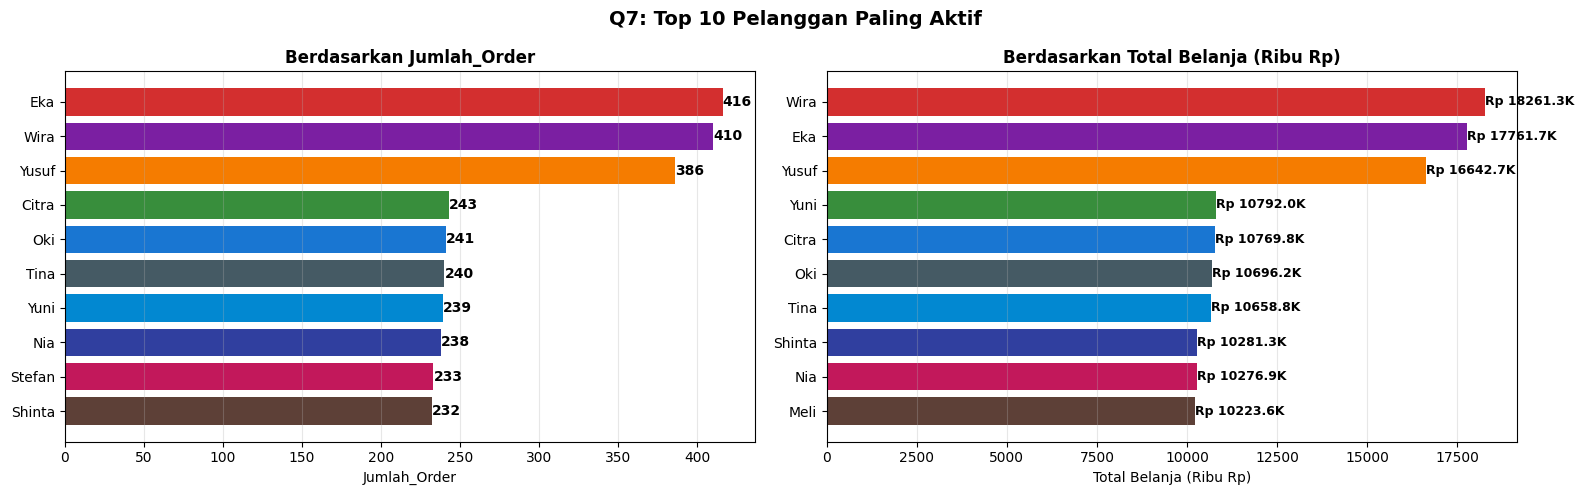

HASIL VISUALISASI Q7✅


In [ ]:
# Visualisasi Top 10 Pelanggan
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Q7: Top 10 Pelanggan Paling Aktif', fontsize=14, fontweight='bold')

COLORS = ['#5D4037','#C2185B','#303F9F','#0288D1','#455A64',
          '#1976D2','#388E3C','#F57C00','#7B1FA2','#D32F2F']

# Chart 1: Jumlah Order
ax1 = axes[0]
bars = ax1.barh(top_pelanggan['customer_name'][::-1],
                top_pelanggan['Jumlah_order'][::-1], color=COLORS)
ax1.set_title('Berdasarkan Jumlah_Order', fontweight='bold')
ax1.set_xlabel('Jumlah_Order')
for bar, val in zip(bars, top_pelanggan['Jumlah_order'][::-1]):
    ax1.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             str(int(val)), va='center', fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# Chart 2: Total Belanja
top_by_belanja = df.groupby('customer_name')['total_sales'].sum().sort_values(ascending=False).head(10)
ax2 = axes[1]
bars2 = ax2.barh(top_by_belanja.index[::-1],
                 top_by_belanja.values[::-1] / 1000, color=COLORS)
ax2.set_title('Berdasarkan Total Belanja (Ribu Rp)', fontweight='bold')
ax2.set_xlabel('Total Belanja (Ribu Rp)')
for bar, val in zip(bars2, top_by_belanja.values[::-1]):
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'Rp {val/1000:.1f}K', va='center', fontsize=9, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('top_pelanggan.png', dpi=150, bbox_inches='tight')
plt.show()
print('HASIL VISUALISASI Q7✅')

In [ ]:
# ============================================================
# Q8: Kategori produk mana yang paling laris di tiap channel?
# Bandingkan performa setiap kategori (Makanan, Pembersih, Perawatan) di masing-masing channel penjualan
# (Offline, Online Toko Oren, Online Toko Hijau), mana yang mendominasi di tiap channel?
# ============================================================

kat_channel = df.groupby(['channel', 'category']).agg(
    Total_Revenue = ('total_sales', 'sum'),
    Jumlah_Order  = ('order_id', 'count'),
    Total_Qty     = ('quantity', 'sum'),
    Avg_Rating    = ('rating', 'mean')
).reset_index()

# pivot table
pivot_rev = df.pivot_table(
    index      = 'category',
    columns    = 'channel',
    values     = 'total_sales',
    aggfunc    = 'sum',
    fill_value = 0
)
pivot_rev['TOTAL'] = pivot_rev.sum(axis=1)
pivot_rev = pivot_rev.sort_values('TOTAL', ascending=False)

print('=== Q8: PIVOT TABLE REVENUE (Rp) per KATEGORI x CHANNEL ===')
print(pivot_rev.applymap(lambda x: f'Rp {x:,.0f}'))

print('\n=== KATEGORI TERLARIS PER CHANNEL ===')
for channel in df['channel'].unique():
    sub = kat_channel[kat_channel['channel'] == channel]
    top = sub.loc[sub['Total_Revenue'].idxmax()]
    print(f'{channel:<22} → {top["category"]} (Rp {top["Total_Revenue"]:,.0f}, {int(top["Jumlah_Order"])} order)')

=== Q8: PIVOT TABLE REVENUE (Rp) per KATEGORI x CHANNEL ===
channel           Offline Online - Toko Hijau Online - Toko Oren  \
category                                                           
Makanan    Rp 114,146,400      Rp 108,796,150     Rp 110,332,750   
Perawatan   Rp 96,116,300       Rp 96,409,950      Rp 93,816,400   
Pembersih   Rp 82,802,100       Rp 85,059,000      Rp 85,143,950   

channel             TOTAL  
category                   
Makanan    Rp 333,275,300  
Perawatan  Rp 286,342,650  
Pembersih  Rp 253,005,050  

=== KATEGORI TERLARIS PER CHANNEL ===
Online - Toko Oren     → Makanan (Rp 110,332,750, 1997 order)
Offline                → Makanan (Rp 114,146,400, 2052 order)
Online - Toko Hijau    → Makanan (Rp 108,796,150, 1970 order)


## 6. Visualisasi Dashboard

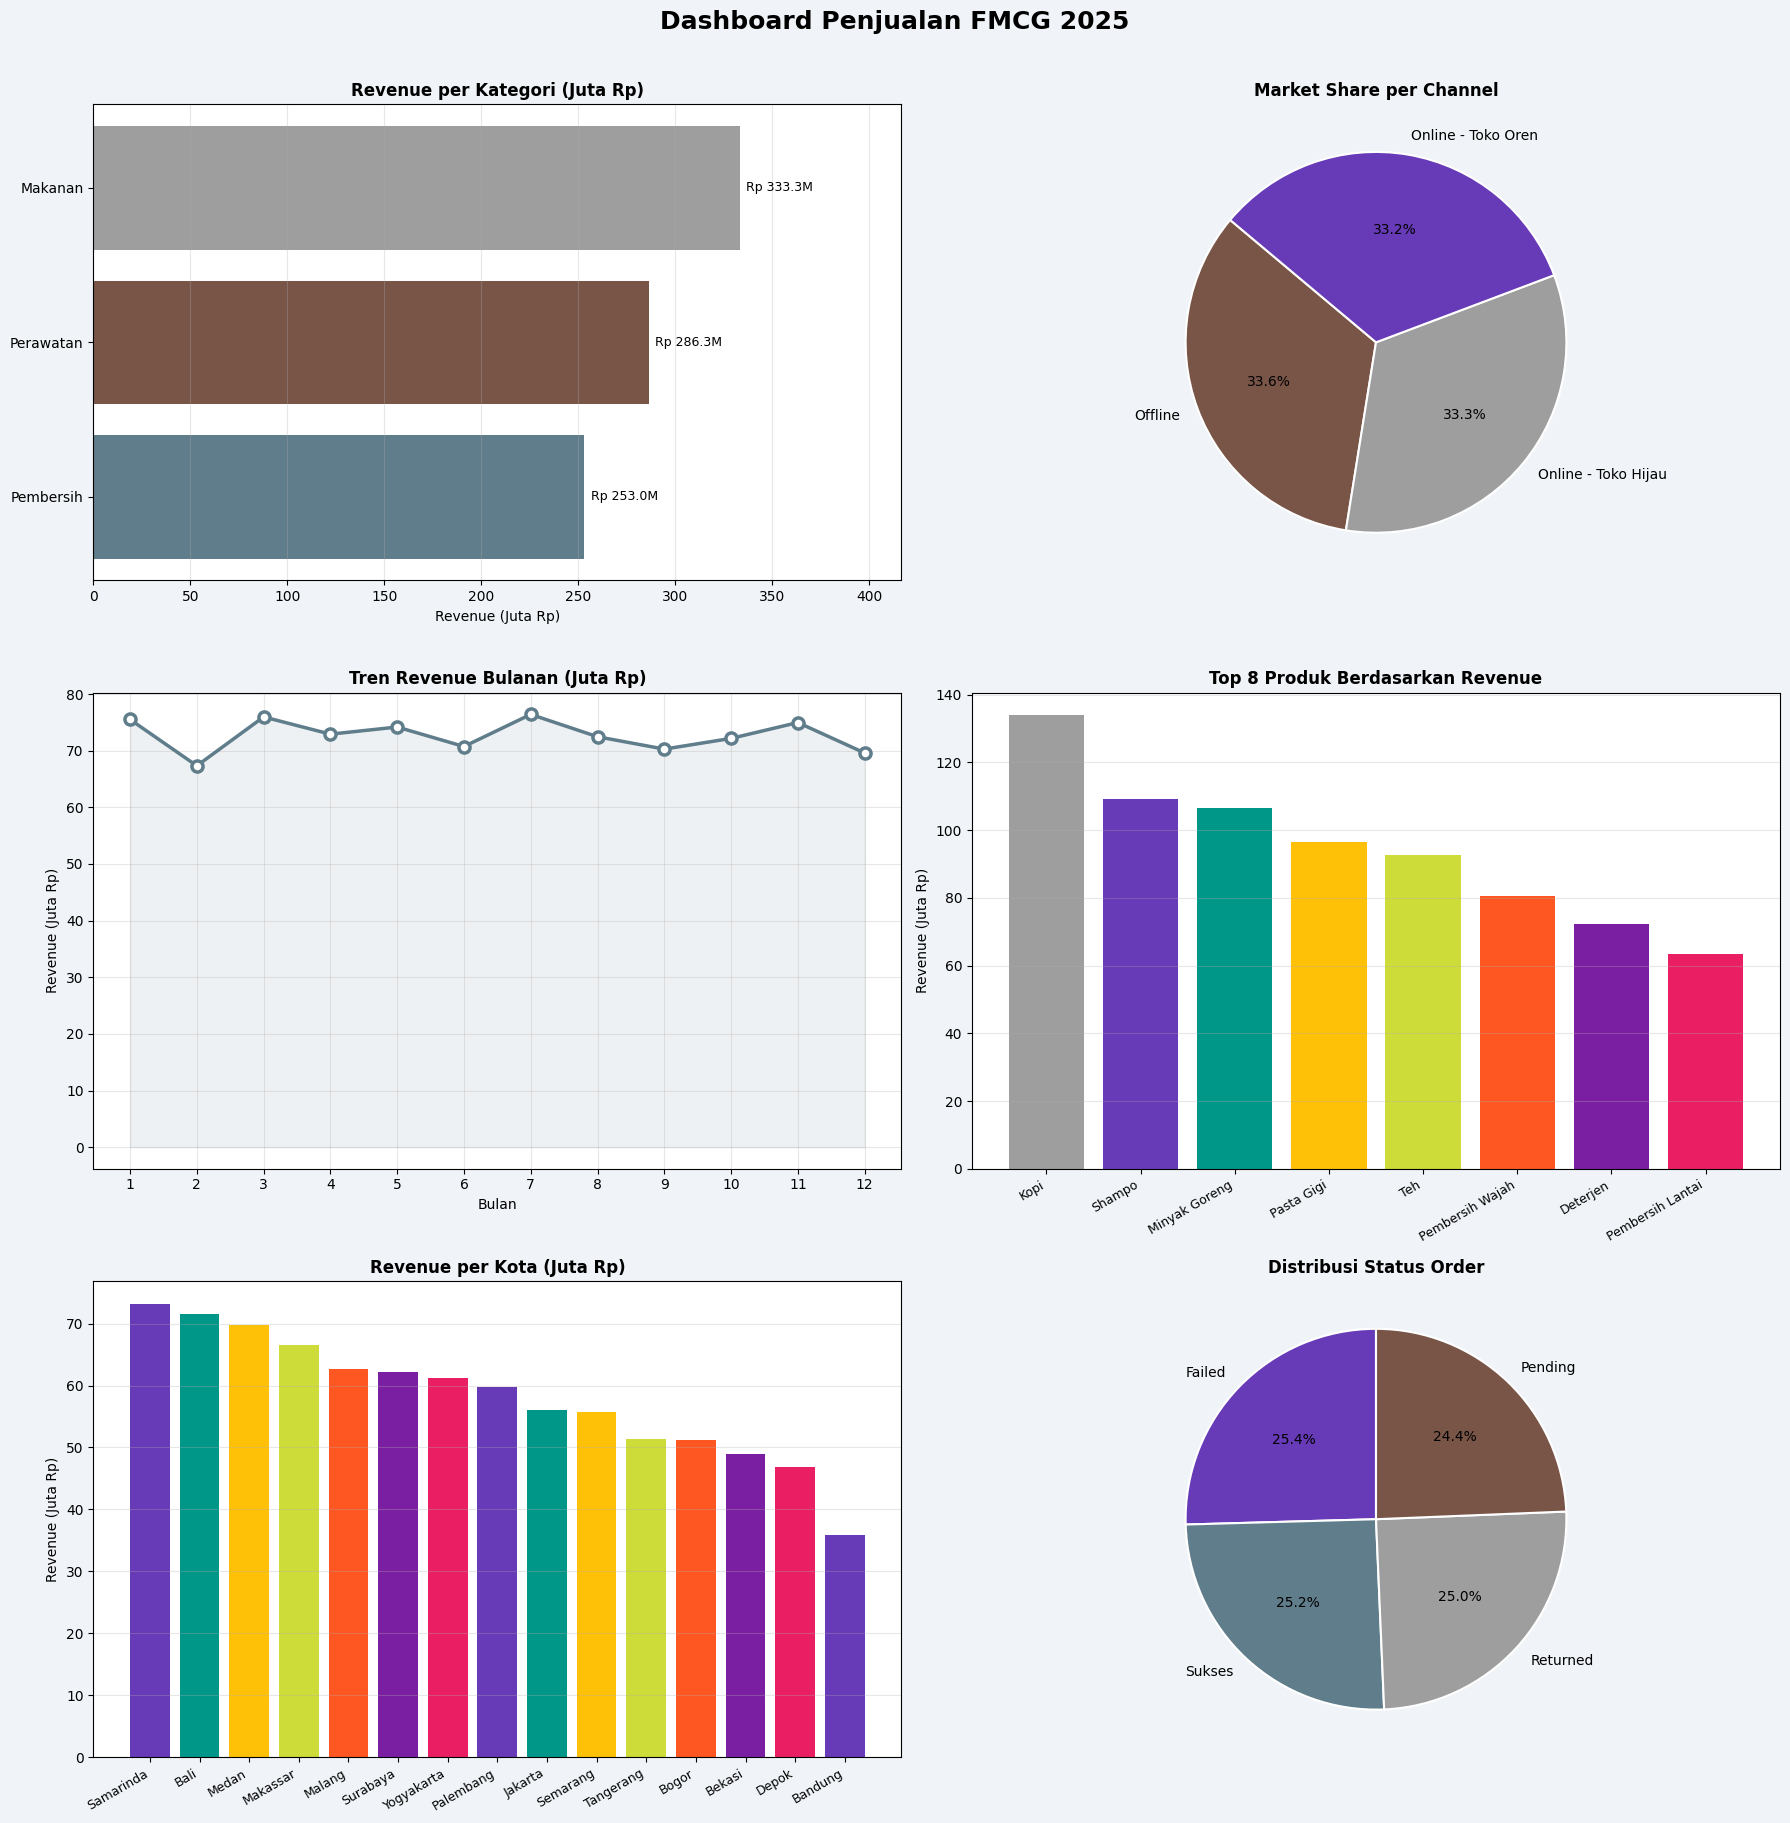

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(18, 18))
fig.suptitle('Dashboard Penjualan FMCG 2025', fontsize=18, fontweight='bold', y=1.01)

# Mengubah warna latar belakang figure
fig.patch.set_facecolor('#F0F4F8') # Warna latar belakang yang lebih terang

# Palet warna baru yang lebih kalem
COLORS = ['#607D8B', '#795548', '#9E9E9E', '#673AB7', '#009688',
          '#FFC107', '#CDDC39', '#FF5722', '#7B1FA2', '#E91E63'] # Muted and less vibrant palette

# --- 1. Revenue per Kategori (Horizontal Bar) ---
ax1 = axes[0, 0]
cat_data = df.groupby('category')['total_sales'].sum().sort_values()
bars = ax1.barh(cat_data.index, cat_data.values / 1e6, color=COLORS[0:len(cat_data)])
ax1.set_title('Revenue per Kategori (Juta Rp)', fontweight='bold')
ax1.set_xlabel('Revenue (Juta Rp)')
for bar, val in zip(bars, cat_data.values):
    ax1.text(bar.get_width() + cat_data.max()/1e6*0.01,
             bar.get_y() + bar.get_height()/2,
             f'Rp {val/1e6:.1f}M', va='center', fontsize=9)
ax1.set_xlim(0, cat_data.max()/1e6 * 1.25)
ax1.grid(axis='x', alpha=0.3)
ax1.set_facecolor('#FFFFFF') # Warna latar belakang subplot

# --- 2. Market Share Channel (Pie) ---
ax2 = axes[0, 1]
ch_data = df.groupby('channel')['total_sales'].sum()
ax2.pie(ch_data.values, labels=ch_data.index, autopct='%1.1f%%',
        colors=COLORS[1:len(ch_data)+1], startangle=140,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax2.set_title('Market Share per Channel', fontweight='bold')
ax2.set_facecolor('#FFFFFF') # Warna latar belakang subplot

# --- 3. Tren Bulanan (Line) ---
ax3 = axes[1, 0]
tren_data = df.groupby('month')['total_sales'].sum()
ax3.plot(tren_data.index, tren_data.values / 1e6, marker='o',
         color=COLORS[0], linewidth=2.5, markersize=8,
         markerfacecolor='white', markeredgewidth=2.5)
ax3.fill_between(tren_data.index, tren_data.values / 1e6, alpha=0.1, color=COLORS[0])
ax3.set_title('Tren Revenue Bulanan (Juta Rp)', fontweight='bold')
ax3.set_xlabel('Bulan')
ax3.set_ylabel('Revenue (Juta Rp)')
ax3.set_xticks(tren_data.index)
ax3.grid(True, alpha=0.3)
ax3.set_facecolor('#FFFFFF') # Warna latar belakang subplot

# --- 4. Top 8 Produk (Bar) ---
ax4 = axes[1, 1]
top8 = df.groupby('product_name')['total_sales'].sum().sort_values(ascending=False).head(8)
ax4.bar(range(len(top8)), top8.values / 1e6, color=COLORS[2:len(top8)+2])
ax4.set_title('Top 8 Produk Berdasarkan Revenue', fontweight='bold')
ax4.set_ylabel('Revenue (Juta Rp)')
ax4.set_xticks(range(len(top8)))
ax4.set_xticklabels(top8.index, rotation=30, ha='right', fontsize=9)
ax4.grid(axis='y', alpha=0.3)
ax4.set_facecolor('#FFFFFF') # Warna latar belakang subplot

# --- 5. Revenue per Kota (Bar) ---
ax5 = axes[2, 0]
kota_data = df.groupby('customer_address')['total_sales'].sum().sort_values(ascending=False)
ax5.bar(range(len(kota_data)), kota_data.values / 1e6, color=COLORS[3:len(kota_data)+3])
ax5.set_title('Revenue per Kota (Juta Rp)', fontweight='bold')
ax5.set_ylabel('Revenue (Juta Rp)')
ax5.set_xticks(range(len(kota_data)))
ax5.set_xticklabels(kota_data.index, rotation=30, ha='right', fontsize=9)
ax5.grid(axis='y', alpha=0.3)
ax5.set_facecolor('#FFFFFF') # Warna latar belakang subplot

# --- 6. Distribusi Status Order (Pie) ---
ax6 = axes[2, 1]
status_data = df['status'].value_counts()
# Menggunakan palet warna yang berbeda untuk status
status_colors = {'Sukses': COLORS[0], 'Pending': COLORS[1],
                 'Returned': COLORS[2], 'Failed': COLORS[3]}
colors_status = [status_colors.get(s, '#9E9E9E') for s in status_data.index]
ax6.pie(status_data.values, labels=status_data.index, autopct='%1.1f%%',
        colors=colors_status, startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax6.set_title('Distribusi Status Order', fontweight='bold')
ax6.set_facecolor('#FFFFFF') # Warna latar belakang subplot

plt.tight_layout()
plt.savefig('dashboard_fmcg.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Executive Summary & Business Insight

In [ ]:
total_rev       = df['total_sales'].sum()
total_order     = df['order_id'].nunique()
avg_order_val   = total_rev / total_order
sukses_rate     = (df['status'] == 'Sukses').mean() * 100
top_kat         = df.groupby('category')['total_sales'].sum().idxmax()
top_channel     = df.groupby('channel')['total_sales'].sum().idxmax()
top_produk_name = df.groupby('product_name')['total_sales'].sum().idxmax()
top_kota        = df.groupby('customer_address')['total_sales'].sum().idxmax()
avg_rating      = df['rating'].mean()
bulan_terbaik   = df.groupby('month_name')['total_sales'].sum().idxmax()

print('╔══════════════════════════════════════════════════════════════╗')
print('║          📊 RINGKASAN EKSEKUTIF - DATA FMCG 2025            ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║ Total Revenue        : Rp {total_rev:>18,.0f}                 ║')
print(f'║ Total Order          : {total_order:>10,} transaksi                  ║')
print(f'║ Avg Order Value      : Rp {avg_order_val:>18,.0f}                 ║')
print(f'║ Success Rate         : {sukses_rate:>9.1f}%                            ║')
print(f'║ Avg Rating           : {avg_rating:>9.2f} / 5                         ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║ 🏆 Kategori Teratas : {top_kat:<40}║')
print(f'║ 📱 Channel Teratas  : {top_channel:<40}║')
print(f'║ 🛍️  Produk Terlaris : {top_produk_name:<40}║')
print(f'║ 🌆 Kota Teratas     : {top_kota:<40}║')
print(f'║ 📅 Bulan Terbaik    : {bulan_terbaik:<40}║')
print('╚══════════════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════════════╗
║          📊 RINGKASAN EKSEKUTIF - DATA FMCG 2025            ║
╠══════════════════════════════════════════════════════════════╣
║ Total Revenue        : Rp        872,623,000                 ║
║ Total Order          :     19,932 transaksi                  ║
║ Avg Order Value      : Rp             43,780                 ║
║ Success Rate         :      25.2%                            ║
║ Avg Rating           :      3.00 / 5                         ║
╠══════════════════════════════════════════════════════════════╣
║ 🏆 Kategori Teratas : Makanan                                 ║
║ 📱 Channel Teratas  : Offline                                 ║
║ 🛍️  Produk Terlaris : Kopi                                    ║
║ 🌆 Kota Teratas     : Samarinda                               ║
║ 📅 Bulan Terbaik    : July                                    ║
╚══════════════════════════════════════════════════════════════╝


In [ ]:
print('=== 💡 BUSINESS INSIGHT & REKOMENDASI ===\n')

insights = [
    (
        '1. Kategori Makanan mendominasi volume transaksi',
        'Pastikan stok produk Makanan (Minyak Goreng, Kopi, Teh) selalu '
        'tersedia karena permintaannya konsisten tinggi sepanjang tahun.'
    ),
    (
        '2. Channel Offline masih menjadi kontributor terbesar revenue',
        'Pertahankan kualitas layanan offline. Paralel, dorong channel '
        'online dengan promo eksklusif untuk menggenjot pertumbuhan digital.'
    ),
    (
        '3. Persentase order Failed & Returned perlu ditekan',
        'Lakukan root-cause analysis pada order yang gagal/dikembalikan. '
        'Periksa apakah masalahnya dari produk, pengiriman, atau ekspektasi pelanggan.'
    ),
    (
        '4. Tren penjualan bulanan tidak merata',
        'Identifikasi bulan-bulan sepi dan jalankan kampanye promosi tematik '
        '(flash sale, bundling) untuk menstabilkan revenue.'
    ),
    (
        '5. Beberapa kota memiliki potensi yang belum dioptimalkan',
        'Fokus ekspansi ke kota dengan order tinggi namun average order value '
        'masih rendah melalui program loyalitas atau strategi up-selling.'
    )
]

for insight, rekomendasi in insights:
    print(f'🔍 Insight      : {insight}')
    print(f'   ✅ Rekomendasi: {rekomendasi}')
    print()

=== 💡 BUSINESS INSIGHT & REKOMENDASI ===

🔍 Insight      : 1. Kategori Makanan mendominasi volume transaksi
   ✅ Rekomendasi: Pastikan stok produk Makanan (Minyak Goreng, Kopi, Teh) selalu tersedia karena permintaannya konsisten tinggi sepanjang tahun.

🔍 Insight      : 2. Channel Offline masih menjadi kontributor terbesar revenue
   ✅ Rekomendasi: Pertahankan kualitas layanan offline. Paralel, dorong channel online dengan promo eksklusif untuk menggenjot pertumbuhan digital.

🔍 Insight      : 3. Persentase order Failed & Returned perlu ditekan
   ✅ Rekomendasi: Lakukan root-cause analysis pada order yang gagal/dikembalikan. Periksa apakah masalahnya dari produk, pengiriman, atau ekspektasi pelanggan.

🔍 Insight      : 4. Tren penjualan bulanan tidak merata
   ✅ Rekomendasi: Identifikasi bulan-bulan sepi dan jalankan kampanye promosi tematik (flash sale, bundling) untuk menstabilkan revenue.

🔍 Insight      : 5. Beberapa kota memiliki potensi yang belum dioptimalkan
   ✅ Rekomendasi: F